In [220]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import re

In [221]:
from datetime import datetime
from isoweek import Week
from cmdstanpy import CmdStanModel
from cmdstanpy import from_csv
import glob

import matplotlib.cm as cm
col1 = plt.cm.inferno(0.3)
col2 = plt.cm.inferno(0.55)
col3 = plt.cm.inferno(0.8)

In [223]:
dt_discrete = 1/8

In [5]:
csv_files = glob.glob('stan_output/sinusoid_2025/*20250801092152*.csv')  # dt=1/8, better prior for S0, 3000 iterations, good diagnostics all around 

print(csv_files)

fit = from_csv(csv_files)

['/home/bjarke/pCloudDrive/PhD/Princeton/Mycoplasma/PNAS_submission/R/Figures/stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_1.csv', '/home/bjarke/pCloudDrive/PhD/Princeton/Mycoplasma/PNAS_submission/R/Figures/stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_2.csv', '/home/bjarke/pCloudDrive/PhD/Princeton/Mycoplasma/PNAS_submission/R/Figures/stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_3.csv', '/home/bjarke/pCloudDrive/PhD/Princeton/Mycoplasma/PNAS_submission/R/Figures/stan_output/sinusoid_2025/sirs_sinusoid_dt-20250801092152_4.csv']


In [224]:
for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'delta']:
    print(f"{var}: {fit.stan_variable(var).mean()}")

S0: 0.6458905435
logx_I0: -2.6409258616666667
beta0: 0.6496458589999999
dbeta: 0.18228653116666668
betaphase: 3.6441056533333334
sigma_obs: 0.016210041683333336
rho: 0.021266319516666667
delta: 0.0023089227783333333


In [225]:
df_draws = fit.draws_pd()
lp = df_draws["lp__"]  # log posterior column
imax = np.argmax(lp)  # index of sample with highest lp__
best_draw = df_draws.iloc[imax]

In [226]:
def best_draw_to_dict(row):
    """
    Convert a series of Stan draws into a structured dict,
    grouping vector parameters like param[1], param[2], ... into arrays.
    """
    result = {}
    for col in row.index:
        # Attempt to match something like "paramName[123]"
        m = re.match(r"(.*)\[(\d+)\]$", col)
        if m:
            base_name = m.group(1)
            idx = int(m.group(2))  # 1-based index from Stan
            val = row[col]

            if base_name not in result:
                # store them in a dict first, convert to array after.
                result[base_name] = {}
            result[base_name][idx] = val
        else:
            # it is a scalar param or a special column like chain__, iter__, ...
            result[col] = row[col]

    # Convert any dict-of-indices to a list or array
    # Stan uses 1-indexing
    for k, v in list(result.items()):
        if isinstance(v, dict):
            # v is a dictionary of indices -> values
            max_idx = max(v.keys())
            # create an array of length = max index
            arr = np.empty(max_idx, dtype=float)
            for i in range(1, max_idx + 1):
                arr[i - 1] = v[i]  # shift to zero-indexing
            result[k] = arr
    return result

best_draw_dict = best_draw_to_dict(best_draw)


In [256]:
# We must translate rates into their continuous time versions: 
def DiscTimeRate(r, dt):
    return (1 - np.exp(-r*dt))/dt


mu = DiscTimeRate(1/(52 * 80.0), dt_discrete)

with_seasonality = True

beta0 = DiscTimeRate(best_draw_dict['beta0'], dt_discrete)
betaphase = best_draw_dict['betaphase']
gamma = DiscTimeRate(best_draw_dict['gamma'], dt_discrete)
delta = DiscTimeRate(best_draw_dict['delta'], dt_discrete)
S0 = best_draw_dict['S0']
I0 = best_draw_dict['I0']



if with_seasonality:
    dbeta = best_draw_dict['dbeta']
else:
    dbeta = 0.0

# Convert all rates to 1/year:
beta0 *= 52
gamma *= 52
mu *= 52
delta *= 52

In [257]:
print(f"beta0 :\t\t {beta0} -- mean transmission rate in units of 1/year")
print(f"dbeta :\t\t {dbeta} -- amplitude of sinusoidal transmission rate fluctuations")
print(f"betaphase :\t {betaphase} -- phase of sinusoidal transmission rate")
print(f"gamma :\t\t {gamma} -- Recovery rate in units of 1/year")
print(f"mu :\t\t {mu} -- Birth/death rate in units of 1/year")
print(f"delta :\t\t {delta} -- Immunity waning rate in units of 1/year. Equals 1/(duration of immunity)")
print(f"S0 :\t\t {S0} -- initial fraction susceptible")
print(f"I0 :\t\t {I0} -- initial fraction infected")

beta0 :		 34.24987930493835 -- mean transmission rate in units of 1/year
dbeta :		 0.183596 -- amplitude of sinusoidal transmission rate fluctuations
betaphase :	 3.64638 -- phase of sinusoidal transmission rate
gamma :		 20.28855940770297 -- Recovery rate in units of 1/year
mu :		 0.012499812201379967 -- Birth/death rate in units of 1/year
delta :		 0.1015020149817083 -- Immunity waning rate in units of 1/year. Equals 1/(duration of immunity)
S0 :		 0.607883 -- initial fraction susceptible
I0 :		 0.001388 -- initial fraction infected


In [290]:
import numpy as np
import numpy.linalg as LA

def sirs_ode(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta):
    # seasonal transmission rate
    beta_t = beta0 * (1 + dbeta*np.sin(2*np.pi*t + betaphase))
    dSdt = mu - beta_t*S*I - mu*S + delta*R
    dIdt = beta_t*S*I - (mu + gamma)*I
    dRdt = gamma*I - (mu + delta)*R
    return np.array([dSdt, dIdt, dRdt])

def sirs_jacobian(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta):
    beta_t = beta0 * (1 + dbeta*np.sin(2*np.pi*t + betaphase))
    
    # build Jacobian
    J = np.zeros((3,3))
    # partial derivatives of dS/dt (wrt S, I and R)
    J[0,0] = -beta_t*I - mu
    J[0,1] = -beta_t*S
    J[0,2] = delta
    # partial derivatives of dI/dt
    J[1,0] = beta_t*I
    J[1,1] = beta_t*S - (mu + gamma)
    J[1,2] = 0.0
    # partial derivatives of dR/dt
    J[2,0] = 0.0
    J[2,1] = gamma
    J[2,2] = -(mu + delta)
    
    return J

def lyapunov_exponents_sirs(beta0, dbeta, betaphase, gamma, mu, delta, 
                            S0, I0, dt=0.05, total_time=20, t0=0.0):
    # number of steps
    N = int(total_time / dt)
    
    S, I, R = S0, I0, 1 - S0 - I0
    
    # initial tangent vectors
    Q = np.eye(3)
    
    # how frequently to re-orthonormalize
    reortho_every = 1

    S_timeseries = np.full(N+1, np.nan)
    I_timeseries = np.full(N+1, np.nan)
    R_timeseries = np.full(N+1, np.nan)
    ts = np.full(N+1, np.nan)
    ts[0] = t0
    S_timeseries[0] = S
    I_timeseries[0] = I
    R_timeseries[0] = R
    
    
    t = t0
    lyaps = np.zeros((3, N+1))
    for k in range(1, N+1):
        # compute the ODE derivatives
        f = sirs_ode(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta)
        
        S += dt * f[0]
        I += dt * f[1]
        R += dt * f[2]
        
        # compute Jacobian at current step
        J = sirs_jacobian(t, S, I, R, beta0, dbeta, betaphase, gamma, mu, delta)
        # tangent vector update: multiply each column of Q by [I + dt*J]
        M = np.eye(3) + dt*J
        Q = M @ Q  
        
        if (k % reortho_every) == 0:
            # do QR decomposition
            Q, Rmat = np.linalg.qr(Q) 
            # get log stretch factors from diagonal of Rmat
            diag = np.abs(np.diag(Rmat))
            lyaps[:,k] = np.log(diag)/dt
        
        t += dt
        ts[k] = t
        S_timeseries[k] = S
        I_timeseries[k] = I
        R_timeseries[k] = R
    
    lyaps[:,0]=lyaps[:,1]
    
    return lyaps, ts, S_timeseries, I_timeseries, R_timeseries

dt = 0.002

LLEs, ts, Ss, Is, Rs = lyapunov_exponents_sirs(beta0, dbeta, betaphase, gamma, mu, delta, 
                               S0, I0, dt=dt, total_time=10)
print("Estimated Lyapunov exponents:", LLEs)
print("Max mean LE =", np.max(np.mean(LLEs,axis=1)))
print("Max point LLE =", np.max(LLEs))

Estimated Lyapunov exponents: [[-0.05570366 -0.05570366 -0.05712255 ... -0.12097392 -0.12059671
  -0.12019707]
 [-0.91527147 -0.91527147 -0.12738404 ... -5.24353214 -5.2811795
  -5.31905203]
 [-0.52749161 -0.52749161 -1.35462423 ...  3.58008028  3.57559993
   3.57161321]]
Max mean LE = 0.11567896860035817
Max point LLE = 10.78498857773473


(0.0, 10.0)

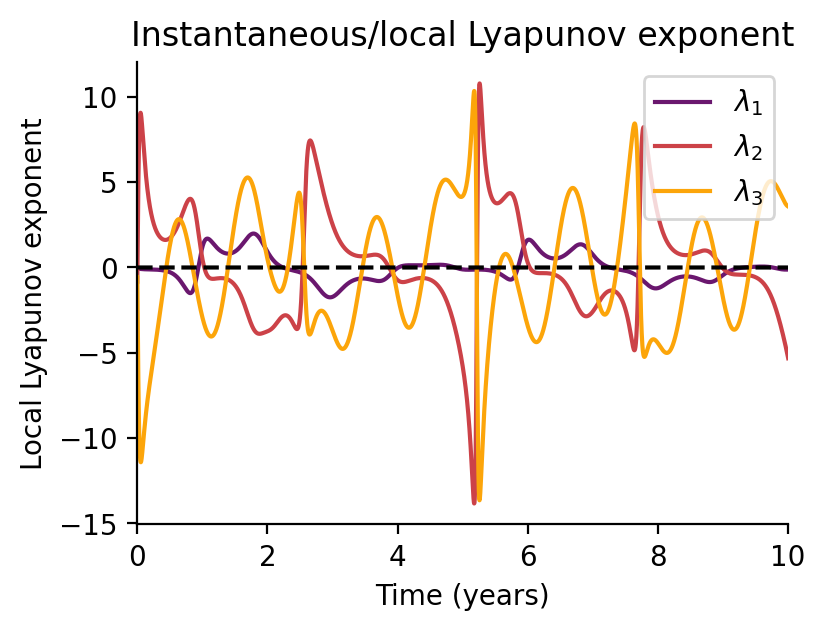

In [294]:
plt.figure(figsize=(4.2, 3), dpi=200)

import matplotlib.cm as cm
col1 = plt.cm.inferno(0.3)
col2 = plt.cm.inferno(0.55)
col3 = plt.cm.inferno(0.8)

#plt.plot(durations_yr, lya_t[0,:], label=r"$\lambda_S$")
plt.plot(ts, LLEs[0,:], label=r"$\lambda_1$", color=col1)
plt.plot(ts, LLEs[1,:], label=r"$\lambda_2$", color=col2)
plt.plot(ts, LLEs[2,:], label=r"$\lambda_3$", color=col3)
#plt.plot(durations_yr, lya_t[1,:], label=r"$\lambda_I$")
#plt.plot(durations_yr, lya_t[2,:], label=r"$\lambda_R$")
plt.plot(ts, [0] * len(ts), "--", color="black")
plt.xlim([ts[0],ts[-1] ])
plt.legend(loc="upper right")
#plt.xlabel("Years averaged over")
plt.ylabel("Local Lyapunov exponent")
plt.xlabel("Time (years)")
plt.title("Instantaneous/local Lyapunov exponent")
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlim([0, 10])

In [296]:
years_to_expand = 10.0
print(f"Expansion over the first {years_to_expand} years:")
print(np.prod(np.exp(LLEs[1, ts <= years_to_expand] * dt)))

Expansion over the first 10.0 years:
3.2144592513093744


In [265]:
lya_t = np.zeros((3, len(ts)))
for i, t_y in enumerate(ts):
    lya_t[0,i] = np.mean(LLEs[0, :i+1])
    lya_t[1,i] = np.mean(LLEs[1, :i+1])
    lya_t[2,i] = np.mean(LLEs[2, :i+1])

## Above was only for 2010 initial condition

# Across many initial conditions:

In [245]:
# Parallel:

from concurrent.futures import ProcessPoolExecutor
total_years = 200
nth = 20
def _one_ic(args):
    
    average = True
    
    S0, I0 = args
    LLEs, ts, Ss, Is, Rs = lyapunov_exponents_sirs(
    #LLEs, ts, Ss, Is, Rs = local_lyapunov_exponents_simpler(
        beta0, dbeta, betaphase, gamma, mu, delta,
        S0, I0, dt=dt, total_time=total_years
    )
    ts = ts
    ts = ts[::nth]
    lya_t = np.zeros((3, len(ts)))
    LLEs = LLEs[:, ::nth]
    for i in range(3):
        if average:
            cs = np.cumsum(LLEs[i, :])
            lya_t[i, :] = cs / np.arange(1, len(ts)+1)
        else:
            lya_t[i, :] = LLEs[i, :]
    max_le10 = float(np.max(np.mean(LLEs[:,ts<10], axis=1) ))
    max_le2 = float(np.max(np.mean(LLEs[:,ts<2], axis=1) ))
    print("Max mean LE =", np.max(np.mean(LLEs,axis=1)))
    return lya_t, max_le10, max_le2

with ProcessPoolExecutor() as ex:
    results = list(ex.map(_one_ic, initial_conditions))

lya_ts = [r[0] for r in results]
i=0
for _, max_le10, max_le2 in results:
    #print("Max 10-year LE =", max_le10, " 10-year expansion:", np.exp(max_le10*10))
    print("Max 2-year LE =", max_le2, " 2-year expansion:", np.exp(max_le2*2), " with IC:", initial_conditions[i])
    i += 1

Max mean LE = -0.012521892416921138
Max mean LE = -0.012520958279648489
Max mean LE = -0.012553499340755874
Max mean LE = -0.012524120416650015
Max mean LE = -0.012520957779765803
Max mean LE = -0.012524147375761312
Max mean LE = -0.012520887949307974
Max mean LE = -0.012520961838921714
Max mean LE = -0.012521902089649681
Max mean LE = -0.012521187151535534
Max mean LE = -0.012531257119992171
Max mean LE = -0.012520971898426778
Max mean LE = -0.012553772059415276
Max mean LE = -0.012521195376808295
Max mean LE = -0.012521899070561702
Max mean LE = -0.01252090333176225
Max mean LE = -0.01253142860712032
Max mean LE = -0.01252419682679714
Max mean LE = -0.012521185763235194
Max mean LE = -0.012521913259840357
Max mean LE = -0.012531341712882678
Max mean LE = -0.012520884874293472
Max mean LE = -0.012554333581111068
Max mean LE = -0.0125211838440378
Max mean LE = -0.012554048749321004
Max mean LE = -0.012520890505975124
Max mean LE = -0.01253117099838365
Max mean LE = -0.01252417079513056

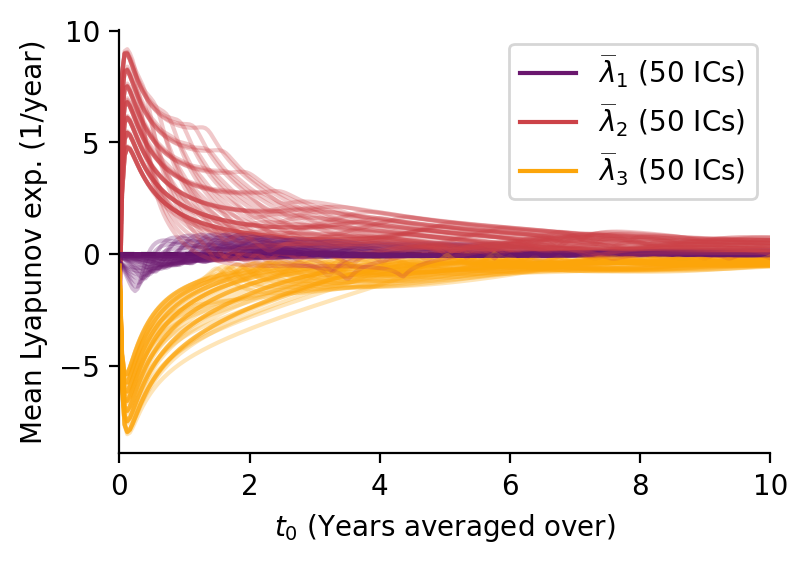

In [246]:
# All the exponents, first 10 years, non-smoothed

window_length = 104

smooth = False

plt.figure(figsize=(4.2, 2.75), dpi=200)
plt.plot(ts, [0] * len(ts), "--", color="black")

from scipy.signal import savgol_filter

alpha_factor = 2.0

it=0
for lya_t in lya_ts:
    for i in range(lya_t.shape[0]):
        cols=[col1, col2, col3]
        # Savitzky-Golay smoothing
        if smooth:
            to_plot = savgol_filter(lya_t[i,:], window_length=window_length, polyorder=2)
        else:
            to_plot = lya_t[i,:]
        if it==0:
            ts = np.linspace(0, total_years, lya_t.shape[1])
            plt.plot(ts, to_plot, label=rf"$\widebar\lambda_{i+1}$ ({len(initial_conditions)} ICs)", color=cols[i], alpha=alpha_factor/IC_steps)
        else:
            plt.plot(ts, to_plot, color=cols[i], alpha=alpha_factor/IC_steps)
    it += 1
    

plt.xlim([0,10])

#plt.xlim([ts[-1]-100, ts[-1]])
#plt.ylim([-2e-4, 2e-4])
#plt.ylim([-0.75e-2, 0.75e-2])
#plt.ylim([-52*0.3e-1, 52*0.3e-1])

#plt.yticks([-5e-3, 0, 5e-3])

leg = plt.legend(loc="upper right")

for lh in leg.legend_handles: 
    lh.set_alpha(1)


plt.xlabel(r"$t_0$ (Years averaged over)")
plt.ylabel("Mean Lyapunov exp. (1/year)")
#plt.title("Mean Lyapunov exp. in interval [0; T]")

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True) 

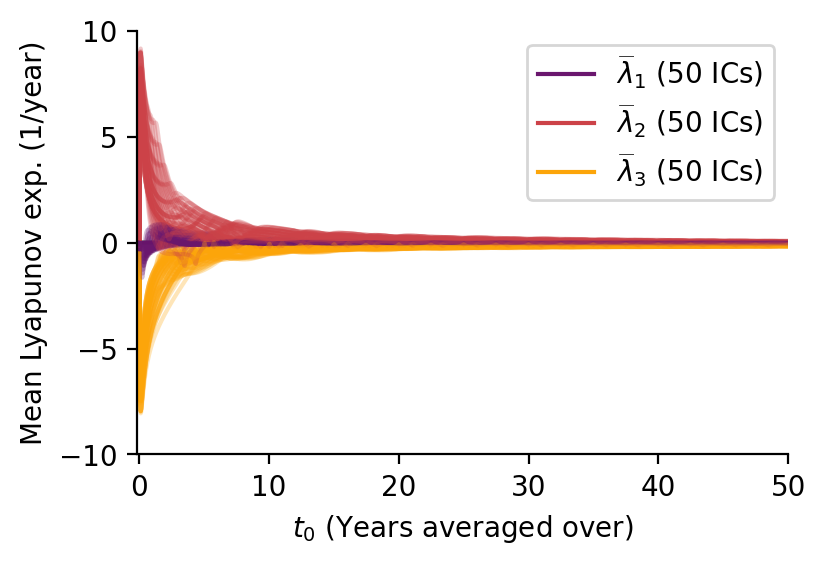

In [247]:
# All the exponents, first 50 years

smooth = False

plt.figure(figsize=(4.2, 2.75), dpi=200)
plt.plot(ts, [0] * len(ts), "--", color="black")

from scipy.signal import savgol_filter

alpha_factor = 2.0

it=0
for lya_t in lya_ts:
    for i in range(lya_t.shape[0]):
        cols=[col1, col2, col3]
        if smooth:
            to_plot = savgol_filter(lya_t[i,:], window_length=104, polyorder=2)
        else:
            to_plot = lya_t[i,:]
        if it==0:
            ts = np.linspace(0, total_years, lya_t.shape[1])
            plt.plot(ts, to_plot, label=rf"$\widebar\lambda_{i+1}$ ({len(initial_conditions)} ICs)", color=cols[i], alpha=alpha_factor/IC_steps)
        else:
            plt.plot(ts, to_plot, color=cols[i], alpha=alpha_factor/IC_steps)
    it += 1
    

plt.xlim([-0.15,50])

#plt.xlim([ts[-1]-100, ts[-1]])
#plt.ylim([-2e-4, 2e-4])

#plt.ylim([-0.75e-2, 0.75e-2])
#plt.ylim([-52*0.75e-2, 52*0.75e-2])

plt.ylim([-10,10])

######plt.yticks([-5e-3, 0, 5e-3])

leg = plt.legend(loc="upper right")

for lh in leg.legend_handles: 
    lh.set_alpha(1)


plt.xlabel(r"$t_0$ (Years averaged over)")
plt.ylabel("Mean Lyapunov exp. (1/year)")
#plt.title("Mean Lyapunov exp. in interval [0; T]")

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True) 

In [249]:
ts[104]-ts[0]

np.float64(4.16)

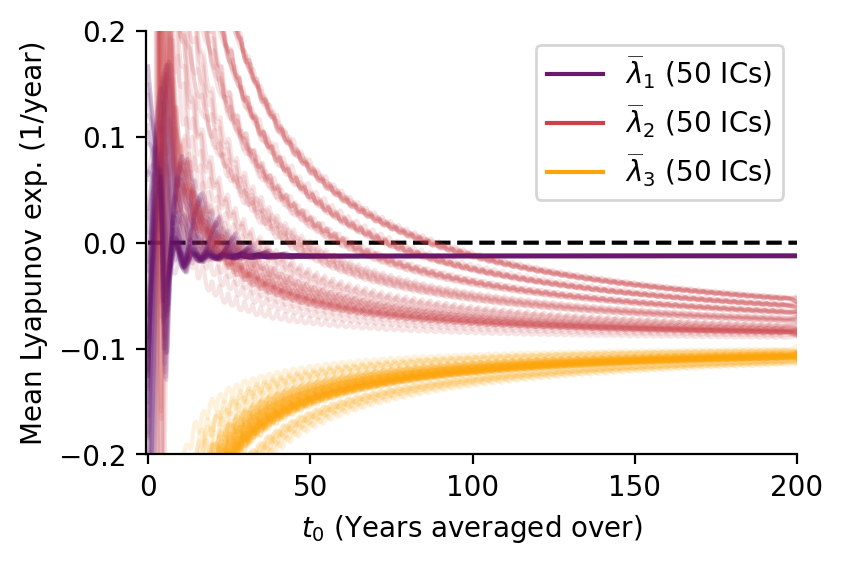

In [251]:
# All the exponents, full time series, but y-axis zoomed in

smooth = True

plt.figure(figsize=(4.2, 2.75), dpi=200)
plt.plot(ts, [0] * len(ts), "--", color="black")

from scipy.signal import savgol_filter

alpha_factor = 1.0

it=0
for lya_t in lya_ts:
    for i in range(lya_t.shape[0]):
        cols=[col1, col2, col3]
        if smooth:
            to_plot = savgol_filter(lya_t[i,:], window_length=200, polyorder=2)
        else:
            to_plot = lya_t[i,:]
        if it==0:
            ts = np.linspace(0, total_years, lya_t.shape[1])
            plt.plot(ts, to_plot, label=rf"$\widebar\lambda_{i+1}$ ({len(initial_conditions)} ICs)", color=cols[i], alpha=alpha_factor/IC_steps)
        else:
            plt.plot(ts, to_plot, color=cols[i], alpha=alpha_factor/IC_steps)
    it += 1
    

plt.xlim([-0.3*2,200])
#plt.xlim([ts[-1]-100, ts[-1]])

#plt.ylim([-52*2e-4, 52*2e-4])

#plt.ylim([-0.75e-2, 0.75e-2])

plt.ylim([-0.2, 0.2])

leg = plt.legend(loc="upper right")

for lh in leg.legend_handles: 
    lh.set_alpha(1)


plt.xlabel(r"$t_0$ (Years averaged over)")
plt.ylabel("Mean Lyapunov exp. (1/year)")
#plt.title("Mean Lyapunov exp. in interval [0; T]")

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True) 
#plt.axhline(-mu, ls="--")